# Анализ пролонгаций проектов — 2023 год

## Описание задачи
Руководитель отдела сопровождения клиентов хочет оценить, насколько хорошо аккаунт-менеджеры справляются с пролонгацией договоров.

## Коэффициенты пролонгации

### К1 — Пролонгация в первый месяц после завершения
**Формула:**
К1(T) = Сумма отгрузки за T проектов, завершившихся в T-1, у которых есть отгрузка в T
        -----------------------------------------------------------------------------
        Сумма отгрузки за T-1 всех проектов, завершившихся в T-1

**Пример (май 2023):** Берём все проекты, завершившиеся в апреле. Суммируем их отгрузку за апрель (знаменатель) и отгрузку тех из них, у кого есть отгрузка в мае (числитель).

### К2 — Пролонгация во второй месяц после завершения
**Формула:**
К2(T) = Сумма отгрузки за T проектов, завершившихся в T-2, без отгрузки в T-1, но с отгрузкой в T
        -----------------------------------------------------------------------------------------
        Сумма отгрузки за T-2 проектов, завершившихся в T-2, без отгрузки в T-1

**Пример (май 2023):** Берём проекты, завершившиеся в марте. Исключаем те, у которых была отгрузка в апреле. Суммируем отгрузку оставшихся за март (знаменатель) и за май (числитель).

## Интерпретация
- **К1 > 1** — отгрузка в первый месяц пролонгации выше последнего месяца реализации
- **К1 = 1** — отгрузка сохраняется на том же уровне
- **К1 < 1** — отгрузка снижается

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 1. Загрузка данных

In [ ]:
df_prol = pd.read_csv('prolongations.csv', encoding='utf-8')
df_fin = pd.read_csv('financial_data.csv', encoding='utf-8')
print(f'prolongations.csv: {df_prol.shape[0]} строк, {df_prol.shape[1]} колонок')
print(f'financial_data.csv: {df_fin.shape[0]} строк, {df_fin.shape[1]} колонок')
print()
print('prolongations.csv — первые 5 строк:')
display(df_prol.head())
print()
print('financial_data.csv — первые 5 строк:')
display(df_fin.head())

prolongations.csv: 477 строк, 3 колонок
financial_data.csv: 451 строк, 19 колонок

prolongations.csv — первые 5 строк:


,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна



financial_data.csv — первые 5 строк:


,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,42,NaN,"36 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
4,665,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


## 2. Приведение названий месяцев к единому формату

In [ ]:
month_cols = [col for col in df_fin.columns if re.search(r'[а-яА-Я]+ \d{4}', col)]
print(f'Колонки с месяцами: {month_cols}')

def parse_month(col_name):
    months_ru = {
        'январь': 1, 'февраль': 2, 'март': 3, 'апрель': 4, 'май': 5, 'июнь': 6,
        'июль': 7, 'август': 8, 'сентябрь': 9, 'октябрь': 10, 'ноябрь': 11, 'декабрь': 12
    }
    parts = col_name.strip().split()
    if len(parts) != 2:
        return None
    month_name, year = parts[0].lower(), parts[1]
    month_num = months_ru.get(month_name)
    if month_num is None or not year.isdigit():
        return None
    return f"{year}-{month_num:02d}"

col_mapping = {}
for col in month_cols:
    std = parse_month(col)
    if std:
        col_mapping[col] = std

df_fin.rename(columns=col_mapping, inplace=True)
std_month_cols = sorted(list(col_mapping.values()))
print(f'Стандартные колонки: {std_month_cols}')

Колонки с месяцами: ['Ноябрь 2022', 'Декабрь 2022', 'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023', 'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023', 'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023', 'Январь 2024', 'Февраль 2024']
Стандартные колонки: ['2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02']


## 3. Обработка специальных значений и перевод в длинный формат

**Важно:** Числовые значения в financial_data.csv имеют формат `36 220,00` (с неразрывным пробелом как разделителем тысяч и запятой как десятичным разделителем).

In [ ]:
def parse_financial_value(val):
    if pd.isna(val):
        return None, False
    val_str = str(val).strip().lower()
    if val_str in ('стоп', 'end', "'стоп'", "'end'"):
        return None, True
    if val_str in ('в ноль', "'в ноль'"):
        return 0.0, False
    val_clean = val_str.replace('\xa0', '').replace('\u202f', '').replace(',', '.')
    try:
        return float(val_clean), False
    except ValueError:
        return None, False

records = []
excluded_projects = set()

for idx, row in df_fin.iterrows():
    pid = row['id']
    for m in std_month_cols:
        val = row[m]
        num_val, is_excluded = parse_financial_value(val)
        if is_excluded:
            excluded_projects.add(pid)
            continue
        if num_val is None:
            continue
        records.append({
            'id': pid, 'month': m, 'value': num_val,
            'account_fin': row.get('Account', None),
            'reason_duplicate': row.get('Причина дубля', None)
        })

df_long = pd.DataFrame(records)
df_long = df_long[~df_long['id'].isin(excluded_projects)]

print(f'Исключённых проектов: {len(excluded_projects)}')
print(f'Записей в длинном формате: {len(df_long)}')
print(f'Уникальных проектов: {df_long["id"].nunique()}')

Исключённых проектов: 55
Записей в длинном формате: 2219
Уникальных проектов: 248


## 4. Агрегация дублей и объединение с данными о пролонгациях

In [ ]:
df_agg = df_long.groupby(['id', 'month'], as_index=False)['value'].sum()

def normalize_prol_month(m):
    m_str = str(m).strip()
    if re.match(r'\d{4}-\d{2}', m_str):
        return m_str
    return parse_month(m_str)

df_prol['month_std'] = df_prol['month'].apply(normalize_prol_month)
df_merged = df_agg.merge(df_prol[['id', 'month_std', 'AM']], on='id', how='left')

nan_am_count = df_merged['AM'].isna().sum()
if nan_am_count > 0:
    print(f'Проектов без AM: {nan_am_count}')
    df_merged['AM'] = df_merged['AM'].fillna('Не назначен')

df_merged['month_dt'] = pd.to_datetime(df_merged['month'] + '-01')
df_merged['end_dt'] = pd.to_datetime(df_merged['month_std'] + '-01')
df_merged = df_merged.sort_values(['id', 'month_dt']).reset_index(drop=True)

print(f'Итого: {len(df_merged)} строк, {df_merged["AM"].nunique()} AM')

Проектов без AM: 6
Итого: 3081 строк, 11 AM


## 5. Расчёт коэффициентов пролонгации

**К1:** проекты, завершившиеся в T-1. Знаменатель = отгрузка за T-1, числитель = отгрузка за T.
**К2:** проекты, завершившиеся в T-2, без отгрузки в T-1. Знаменатель = отгрузка за T-2, числитель = отгрузка за T.

In [ ]:
def calc_coeffs_for_month(df, target_month):
    T = target_month
    T_1 = T - pd.DateOffset(months=1)
    T_2 = T - pd.DateOffset(months=2)

    ended_prev = df[df['end_dt'] == T_1].copy()
    denom_k1_series = ended_prev[ended_prev['month_dt'] == T_1].groupby('AM')['value'].sum()
    num_k1_series = ended_prev[ended_prev['month_dt'] == T].groupby('AM')['value'].sum()

    ended_t2 = df[df['end_dt'] == T_2].copy()
    proj_with_shipment_t1 = set(df[df['month_dt'] == T_1]['id'])
    ended_t2_no_ship = ended_t2[~ended_t2['id'].isin(proj_with_shipment_t1)]
    denom_k2_series = ended_t2_no_ship[ended_t2_no_ship['month_dt'] == T_2].groupby('AM')['value'].sum()
    num_k2_series = ended_t2_no_ship[ended_t2_no_ship['month_dt'] == T].groupby('AM')['value'].sum()

    all_ams = set(denom_k1_series.index) | set(num_k1_series.index) | set(denom_k2_series.index) | set(num_k2_series.index)

    result = {}
    details = []
    total_k1_num, total_k1_denom, total_k2_num, total_k2_denom = 0, 0, 0, 0

    for am in all_ams:
        d1 = denom_k1_series.get(am, 0)
        n1 = num_k1_series.get(am, 0)
        d2 = denom_k2_series.get(am, 0)
        n2 = num_k2_series.get(am, 0)
        k1 = n1 / d1 if d1 != 0 else np.nan
        k2 = n2 / d2 if d2 != 0 else np.nan
        result[am] = {'K1': k1, 'K2': k2}
        details.append({
            'Месяц': T.strftime('%Y-%m'), 'Менеджер': am,
            'K1_числитель': n1, 'K1_знаменатель': d1,
            'K2_числитель': n2, 'K2_знаменатель': d2, 'K1': k1, 'K2': k2
        })
        total_k1_num += n1; total_k1_denom += d1
        total_k2_num += n2; total_k2_denom += d2

    k1_total = total_k1_num / total_k1_denom if total_k1_denom != 0 else np.nan
    k2_total = total_k2_num / total_k2_denom if total_k2_denom != 0 else np.nan
    result['ОТДЕЛ'] = {'K1': k1_total, 'K2': k2_total}
    details.append({
        'Месяц': T.strftime('%Y-%m'), 'Менеджер': 'ОТДЕЛ',
        'K1_числитель': total_k1_num, 'K1_знаменатель': total_k1_denom,
        'K2_числитель': total_k2_num, 'K2_знаменатель': total_k2_denom,
        'K1': k1_total, 'K2': k2_total
    })
    return result, pd.DataFrame(details)

## 6. Месячные коэффициенты за все 12 месяцев 2023 года

In [ ]:
all_months_dt = sorted(df_merged['month_dt'].dropna().unique())
months_2023 = [m for m in all_months_dt if m.year == 2023]
print(f'Расчёт для: {[m.strftime("%Y-%m") for m in months_2023]}')

monthly_results = []
all_details = []
for m in months_2023:
    res, details = calc_coeffs_for_month(df_merged, m)
    for manager, vals in res.items():
        monthly_results.append({
            'Месяц': m.strftime('%Y-%m'), 'Менеджер': manager,
            'К1': vals['K1'], 'К2': vals['K2']
        })
    all_details.append(details)

df_monthly = pd.DataFrame(monthly_results)
df_details = pd.concat(all_details, ignore_index=True)
print(f'Результатов: {len(df_monthly)} строк')
print('ОТДЕЛ:')
display(df_monthly[df_monthly['Менеджер'] == 'ОТДЕЛ'])

Расчёт для: ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']


Результатов: 87 строк
ОТДЕЛ:


,Месяц,Менеджер,К1,К2
7,2023-01,ОТДЕЛ,0.443607,0.134637
15,2023-02,ОТДЕЛ,0.764581,0.050060
22,2023-03,ОТДЕЛ,0.629357,0.183071
30,2023-04,ОТДЕЛ,0.359222,0.092300
37,2023-05,ОТДЕЛ,0.530317,0.000000
44,2023-06,ОТДЕЛ,0.249892,0.038059
51,2023-07,ОТДЕЛ,0.528062,0.124055
57,2023-08,ОТДЕЛ,0.487207,0.036017
64,2023-09,ОТДЕЛ,0.327269,0.000000
71,2023-10,ОТДЕЛ,0.795565,0.041200


## 7. Годовые коэффициенты (средневзвешенное: сумма числителей / сумма знаменателей)

In [ ]:
df_annual_agg = df_details[df_details['Менеджер'] != 'ОТДЕЛ'].groupby('Менеджер').agg({
    'K1_числитель': 'sum', 'K1_знаменатель': 'sum',
    'K2_числитель': 'sum', 'K2_знаменатель': 'sum'
}).reset_index()

df_annual_agg['К1_год'] = df_annual_agg['K1_числитель'] / df_annual_agg['K1_знаменатель']
df_annual_agg['К2_год'] = df_annual_agg['K2_числитель'] / df_annual_agg['K2_знаменатель']
df_annual_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

total_k1_num = df_annual_agg['K1_числитель'].sum()
total_k1_denom = df_annual_agg['K1_знаменатель'].sum()
total_k2_num = df_annual_agg['K2_числитель'].sum()
total_k2_denom = df_annual_agg['K2_знаменатель'].sum()

total_row = pd.DataFrame([{
    'Менеджер': 'ОТДЕЛ',
    'K1_числитель': total_k1_num, 'K1_знаменатель': total_k1_denom,
    'K2_числитель': total_k2_num, 'K2_знаменатель': total_k2_denom,
    'К1_год': total_k1_num / total_k1_denom if total_k1_denom != 0 else np.nan,
    'К2_год': total_k2_num / total_k2_denom if total_k2_denom != 0 else np.nan
}])
df_annual_agg = pd.concat([df_annual_agg, total_row], ignore_index=True)

print('Годовые коэффициенты пролонгации за 2023 год:')
display(df_annual_agg[['Менеджер', 'К1_год', 'К2_год']])

Годовые коэффициенты пролонгации за 2023 год:


,Менеджер,К1_год,К2_год
0,Васильев Артем Александрович,0.485508,0.062796
1,Иванова Мария Сергеевна,0.343606,0.000000
2,Кузнецов Михаил Иванович,0.575870,0.000000
3,Михайлов Андрей Сергеевич,0.664941,0.000000
4,Петрова Анна Дмитриевна,1.111182,NaN
5,Попова Екатерина Николаевна,0.438234,0.051608
6,Смирнова Ольга Владимировна,0.683484,0.253671
7,Соколова Анастасия Викторовна,0.590155,0.065479
8,ОТДЕЛ,0.523011,0.057752


## 8. Дополнительные метрики для руководителя

In [ ]:
projects_per_am = df_prol.groupby('AM')['id'].nunique().reset_index()
projects_per_am.columns = ['Менеджер', 'Кол-во завершённых проектов']

df_with_end = df_merged[df_merged['month'] == df_merged['month_std']].copy()
last_month_shipment = df_with_end.groupby('AM')['value'].agg(['sum', 'mean', 'count']).reset_index()
last_month_shipment.columns = ['Менеджер', 'Сумма за посл. месяц', 'Средняя за посл. месяц', 'Кол-во отгрузок']

df_merged['has_shipment_next_month'] = False
for idx, row in df_merged.iterrows():
    next_month = row['end_dt'] + pd.DateOffset(months=1)
    has_next = df_merged[(df_merged['id'] == row['id']) & (df_merged['month_dt'] == next_month)].shape[0] > 0
    df_merged.at[idx, 'has_shipment_next_month'] = has_next

proj_level = df_merged.groupby(['id', 'AM', 'end_dt']).agg({'has_shipment_next_month': 'max'}).reset_index()
prolongation_rate = proj_level.groupby('AM')['has_shipment_next_month'].agg(['mean', 'sum', 'count']).reset_index()
prolongation_rate.columns = ['Менеджер', 'Доля пролонг. 1-й мес', 'Кол-во пролонг.', 'Всего проектов']
prolongation_rate['Доля пролонг. 1-й мес'] = prolongation_rate['Доля пролонг. 1-й мес'].round(4)

df_extra = projects_per_am.merge(last_month_shipment, on='Менеджер', how='outer')
df_extra = df_extra.merge(prolongation_rate[['Менеджер', 'Доля пролонг. 1-й мес', 'Кол-во пролонг.']], on='Менеджер', how='outer')
print('Дополнительные метрики:')
display(df_extra)

Дополнительные метрики:


,Менеджер,Кол-во завершённых проектов,Сумма за посл. месяц,Средняя за посл. месяц,Кол-во отгрузок,Доля пролонг. 1-й мес,Кол-во пролонг.
0,Васильев Артем Александрович,92,14463103.75,131482.761364,110,0.4907,53
1,Иванова Мария Сергеевна,42,4500507.16,125014.087778,36,0.3889,14
2,Кузнецов Михаил Иванович,17,1440220.50,80012.250000,18,0.5500,11
3,Михайлов Андрей Сергеевич,24,4353448.59,174137.943600,25,0.6154,16
4,Петрова Анна Дмитриевна,1,98492.00,98492.000000,1,1.0000,1
5,Попова Екатерина Николаевна,58,4489871.90,73604.457377,61,0.4262,26
6,Смирнова Ольга Владимировна,53,4221628.39,74063.655965,57,0.4655,27
7,Соколова Анастасия Викторовна,60,7281570.79,102557.335070,71,0.4730,35
8,Федорова Марина Васильевна,2,50250.00,50250.000000,1,0.0000,0
9,без А/М,2,0.00,0.000000,1,0.0000,0


## 9. Визуализация

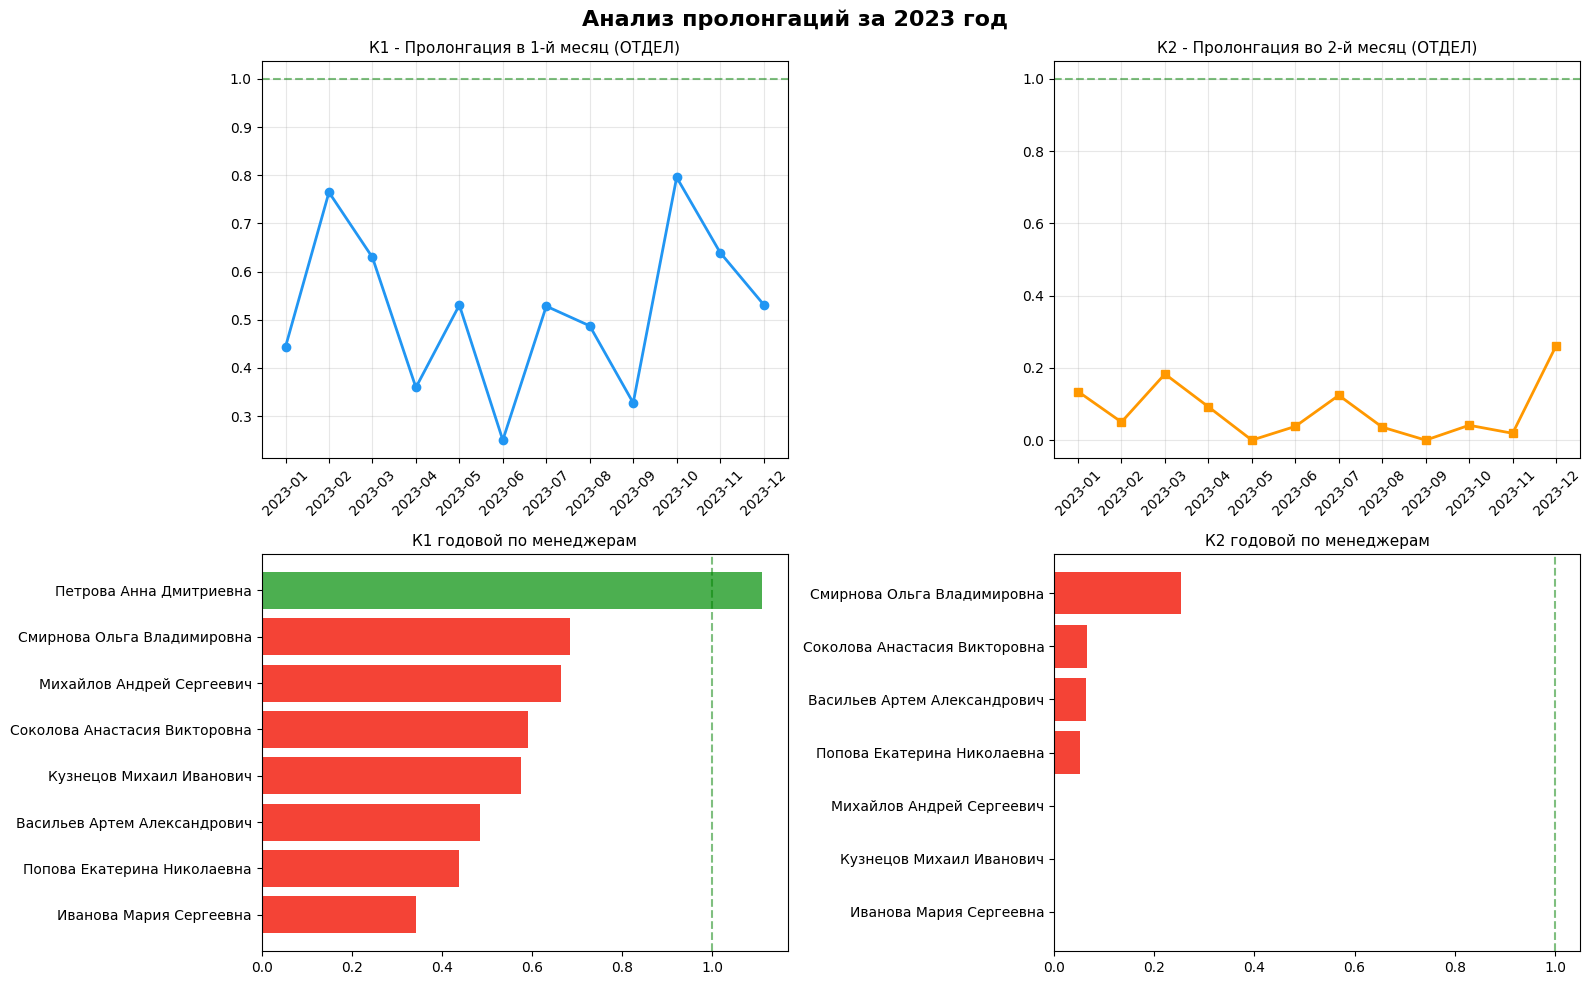

Графики сохранены: prolongation_charts.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Анализ пролонгаций за 2023 год', fontsize=16, fontweight='bold')

dept = df_monthly[df_monthly['Менеджер'] == 'ОТДЕЛ'].copy()

axes[0, 0].plot(dept['Месяц'], dept['К1'], marker='o', linewidth=2, color='#2196F3')
axes[0, 0].axhline(y=1, color='green', linestyle='--', alpha=0.5)
axes[0, 0].set_title('К1 - Пролонгация в 1-й месяц (ОТДЕЛ)', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(dept['Месяц'], dept['К2'], marker='s', linewidth=2, color='#FF9800')
axes[0, 1].axhline(y=1, color='green', linestyle='--', alpha=0.5)
axes[0, 1].set_title('К2 - Пролонгация во 2-й месяц (ОТДЕЛ)', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

annual_managers = df_annual_agg[df_annual_agg['Менеджер'] != 'ОТДЕЛ'].sort_values('К1_год', ascending=True)
colors_k1 = ['#4CAF50' if v >= 1 else '#F44336' for v in annual_managers['К1_год']]
axes[1, 0].barh(annual_managers['Менеджер'], annual_managers['К1_год'], color=colors_k1)
axes[1, 0].axvline(x=1, color='green', linestyle='--', alpha=0.5)
axes[1, 0].set_title('К1 годовой по менеджерам', fontsize=11)

annual_managers2 = df_annual_agg[df_annual_agg['Менеджер'] != 'ОТДЕЛ'].sort_values('К2_год', ascending=True)
colors_k2 = ['#4CAF50' if v >= 1 else '#F44336' for v in annual_managers2['К2_год']]
axes[1, 1].barh(annual_managers2['Менеджер'], annual_managers2['К2_год'], color=colors_k2)
axes[1, 1].axvline(x=1, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_title('К2 годовой по менеджерам', fontsize=11)

plt.tight_layout()
plt.savefig('prolongation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Графики сохранены: prolongation_charts.png')

## 10. Экспорт в Excel

In [ ]:
with pd.ExcelWriter('prolongation_report.xlsx', engine='xlsxwriter') as writer:
    workbook = writer.book
    header_format = workbook.add_format({'bold': True, 'bg_color': '#2196F3', 'font_color': 'white', 'border': 1, 'align': 'center'})
    percent_format = workbook.add_format({'num_format': '0.00%', 'border': 1, 'align': 'center'})
    number_format = workbook.add_format({'num_format': '#,##0.00', 'border': 1, 'align': 'center'})
    text_format = workbook.add_format({'border': 1, 'align': 'left'})
    title_format = workbook.add_format({'bold': True, 'font_size': 14, 'font_color': '#1565C0'})

    def apply_fmt(ws, df):
        for c, name in enumerate(df.columns):
            ws.write(0, c, name, header_format)
        ws.set_column(0, 0, 25, text_format)
        for c in range(1, len(df.columns)):
            ws.set_column(c, c, 14, percent_format)

    pivot_k1 = df_monthly[df_monthly['Менеджер'] != 'ОТДЕЛ'].pivot(index='Менеджер', columns='Месяц', values='К1')
    pivot_k1.loc['ОТДЕЛ'] = df_monthly[df_monthly['Менеджер'] == 'ОТДЕЛ'].set_index('Менеджер')['К1'].values
    pivot_k1 = pivot_k1.reindex(sorted(pivot_k1.columns), axis=1)
    pivot_k1.to_excel(writer, sheet_name='К1_месяц', startrow=2)
    ws1 = writer.sheets['К1_месяц']
    ws1.write('A1', 'Коэффициент пролонгации К1 (1-й месяц)', title_format)
    apply_fmt(ws1, pivot_k1.reset_index())

    pivot_k2 = df_monthly[df_monthly['Менеджер'] != 'ОТДЕЛ'].pivot(index='Менеджер', columns='Месяц', values='К2')
    pivot_k2.loc['ОТДЕЛ'] = df_monthly[df_monthly['Менеджер'] == 'ОТДЕЛ'].set_index('Менеджер')['К2'].values
    pivot_k2 = pivot_k2.reindex(sorted(pivot_k2.columns), axis=1)
    pivot_k2.to_excel(writer, sheet_name='К2_месяц', startrow=2)
    ws2 = writer.sheets['К2_месяц']
    ws2.write('A1', 'Коэффициент пролонгации К2 (2-й месяц)', title_format)
    apply_fmt(ws2, pivot_k2.reset_index())

    df_annual_out = df_annual_agg[['Менеджер', 'К1_год', 'К2_год']].copy()
    df_annual_out.columns = ['Менеджер', 'К1 (1-й месяц)', 'К2 (2-й месяц)']
    df_annual_out.to_excel(writer, sheet_name='Годовые_итоги', startrow=2, index=False)
    ws3 = writer.sheets['Годовые_итоги']
    ws3.write('A1', 'Годовые коэффициенты за 2023 год', title_format)
    apply_fmt(ws3, df_annual_out)

    dept_trend = df_monthly[df_monthly['Менеджер'] == 'ОТДЕЛ'].sort_values('Месяц')
    dept_trend.to_excel(writer, sheet_name='Динамика_отдела', startrow=2, index=False)
    ws4 = writer.sheets['Динамика_отдела']
    ws4.write('A1', 'Динамика коэффициентов по отделу', title_format)
    apply_fmt(ws4, dept_trend)

    df_details.to_excel(writer, sheet_name='Детали_расчёта', startrow=2, index=False)
    ws5 = writer.sheets['Детали_расчёта']
    ws5.write('A1', 'Детализация: числители и знаменатели', title_format)
    for c, name in enumerate(df_details.columns):
        ws5.write(2, c, name, header_format)
    ws5.set_column(0, 0, 12, text_format)
    ws5.set_column(1, 1, 25, text_format)
    for c in range(2, len(df_details.columns)):
        ws5.set_column(c, c, 16, number_format)

    df_extra.to_excel(writer, sheet_name='Доп_метрики', startrow=2, index=False)
    ws6 = writer.sheets['Доп_метрики']
    ws6.write('A1', 'Дополнительные метрики', title_format)
    for c, name in enumerate(df_extra.columns):
        ws6.write(2, c, name, header_format)
    ws6.set_column(0, 0, 25, text_format)
    for c in range(1, len(df_extra.columns)):
        ws6.set_column(c, c, 18, number_format)

print('Отчёт создан: prolongation_report.xlsx')

Отчёт создан: prolongation_report.xlsx


## Итоги

### Что было сделано:
1. **Загружены данные** из `prolongations.csv` и `financial_data.csv`
2. **Обработаны специальные значения**: "стоп"/"end" (исключены), "в ноль" (= 0)
3. **Спарсены числовые значения** в формате `36 220,00` (с неразрывным пробелом и запятой)
4. **Агрегированы дубли** проектов (суммирование отгрузок)
5. **Рассчитаны коэффициенты К1 и К2** по формулам из ТЗ за все 12 месяцев 2023 года
6. **Годовые коэффициенты** как средневзвешенное (сумма числителей / сумма знаменателей)
7. **Дополнительные метрики**: количество проектов, средняя отгрузка, доля пролонгированных
8. **Визуализация**: графики динамики К1 и К2, сравнение менеджеров
9. **Excel-отчёт** с 6 листами и форматированием

### Формулы:
- **К1(T)** = Σ(отгрузка за T проектов, завершённых в T-1, с отгрузкой в T) / Σ(отгрузка за T-1 всех проектов, завершённых в T-1)
- **К2(T)** = Σ(отгрузка за T проектов, завершённых в T-2, без отгрузки в T-1, с отгрузкой в T) / Σ(отгрузка за T-2 проектов, завершённых в T-2, без отгрузки в T-1)